In [92]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## Load dataset

In [93]:
loan_df = pd.read_csv("../data/raw/loan_approval_dataset.csv")
print(f"dataframe shape: {loan_df.shape},\n top 5 records: \n{loan_df.head(5)}")

dataframe shape: (4269, 13),
 top 5 records: 
   loan_id  no_of_dependents      education  self_employed   income_annum  \
0        1                 2       Graduate             No        9600000   
1        2                 0   Not Graduate            Yes        4100000   
2        3                 3       Graduate             No        9100000   
3        4                 3       Graduate             No        8200000   
4        5                 5   Not Graduate            Yes        9800000   

    loan_amount   loan_term   cibil_score   residential_assets_value  \
0      29900000          12           778                    2400000   
1      12200000           8           417                    2700000   
2      29700000          20           506                    7100000   
3      30700000           8           467                   18200000   
4      24200000          20           382                   12400000   

    commercial_assets_value   luxury_assets_value   bank_a

### Basic Understanding

In [94]:
print(f"Summary:")
loan_df.info()

Summary:
<class 'pandas.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   loan_id                    4269 non-null   int64
 1   no_of_dependents           4269 non-null   int64
 2    education                 4269 non-null   str  
 3    self_employed             4269 non-null   str  
 4    income_annum              4269 non-null   int64
 5    loan_amount               4269 non-null   int64
 6    loan_term                 4269 non-null   int64
 7    cibil_score               4269 non-null   int64
 8    residential_assets_value  4269 non-null   int64
 9    commercial_assets_value   4269 non-null   int64
 10   luxury_assets_value       4269 non-null   int64
 11   bank_asset_value          4269 non-null   int64
 12   loan_status               4269 non-null   str  
dtypes: int64(10), str(3)
memory usage: 433.7 KB


In [95]:
loan_df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


In [96]:
# Change the values of all numeric columns of the dataframe upto 2 point decimal

pd.set_option('display.float_format', '{:.2f}'.format)
loan_df.describe()

,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00,4269.00
mean,2135.00,2.50,5059123.92,15133450.46,10.90,599.94,7472616.54,4973155.31,15126305.93,4976692.43
std,1232.50,1.70,2806839.83,9043362.98,5.71,172.43,6503636.59,4388966.09,9103753.67,3250185.31
min,1.00,0.00,200000.00,300000.00,2.00,300.00,-100000.00,0.00,300000.00,0.00
25%,1068.00,1.00,2700000.00,7700000.00,6.00,453.00,2200000.00,1300000.00,7500000.00,2300000.00
50%,2135.00,3.00,5100000.00,14500000.00,10.00,600.00,5600000.00,3700000.00,14600000.00,4600000.00
75%,3202.00,4.00,7500000.00,21500000.00,16.00,748.00,11300000.00,7600000.00,21700000.00,7100000.00
max,4269.00,5.00,9900000.00,39500000.00,20.00,900.00,29100000.00,19400000.00,39200000.00,14700000.00


### Data Quality Issues

In [97]:
# Check for missing values
loan_df.isnull().sum()

loan_id                      0
no_of_dependents             0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [98]:
# Check for duplicate values
loan_df.duplicated().sum()

np.int64(0)

In [99]:
# check column names
loan_df.columns

Index(['loan_id', 'no_of_dependents', ' education', ' self_employed',
       ' income_annum', ' loan_amount', ' loan_term', ' cibil_score',
       ' residential_assets_value', ' commercial_assets_value',
       ' luxury_assets_value', ' bank_asset_value', ' loan_status'],
      dtype='str')

In [100]:
# strip extra spaces
loan_df.columns = loan_df.columns.str.strip()
print(loan_df.columns)

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='str')


In [101]:
for col in loan_df.select_dtypes(include="str"):
    loan_df[col] = loan_df[col].str.strip()

In [102]:
# Check data types
loan_df.dtypes

loan_id                     int64
no_of_dependents            int64
education                     str
self_employed                 str
income_annum                int64
loan_amount                 int64
loan_term                   int64
cibil_score                 int64
residential_assets_value    int64
commercial_assets_value     int64
luxury_assets_value         int64
bank_asset_value            int64
loan_status                   str
dtype: object

### Target Analysis

In [103]:
loan_df["loan_status"].value_counts()

loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64

In [104]:
loan_df["loan_status"].value_counts(normalize=True) * 100

loan_status
Approved   62.22
Rejected   37.78
Name: proportion, dtype: float64

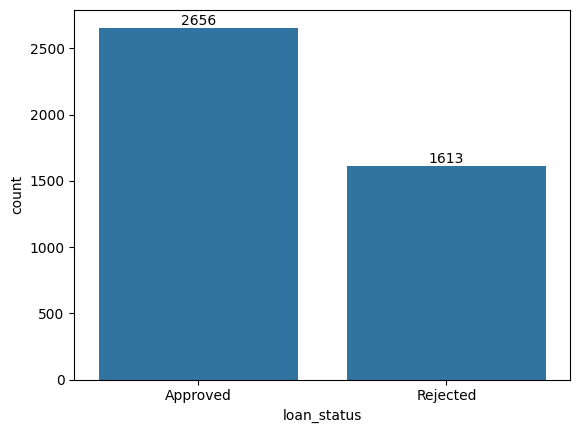

In [105]:
ax = sns.countplot(
    x="loan_status",
    data=loan_df
)
for container in ax.containers:
    ax.bar_label(container)

plt.show()

### Categorical Analysis

In [106]:
categorical_cols = loan_df.select_dtypes(include="str").columns
categorical_cols

Index(['education', 'self_employed', 'loan_status'], dtype='str')

In [107]:
for col in categorical_cols:
    print(loan_df[col].value_counts())

education
Graduate        2144
Not Graduate    2125
Name: count, dtype: int64
self_employed
Yes    2150
No     2119
Name: count, dtype: int64
loan_status
Approved    2656
Rejected    1613
Name: count, dtype: int64


In [108]:
# Change data type of loan_id
loan_df["loan_id"] = loan_df["loan_id"].astype(str)

### Numerical Feature Analysis

In [109]:
numerical_columns = [
    col
    for col in loan_df.select_dtypes(include=["int64", "float64"]).columns
    if col != "loan_status"
]

skew_df = pd.DataFrame({
    "feature": numerical_columns,
    "skewness": [loan_df[col].skew() for col in numerical_columns]
})

skew_df.sort_values(
    by="skewness",
    key=abs,
    ascending=False
)

,feature,skewness
5,residential_assets_value,0.98
6,commercial_assets_value,0.96
8,bank_asset_value,0.56
7,luxury_assets_value,0.32
2,loan_amount,0.31
3,loan_term,0.04
0,no_of_dependents,-0.02
1,income_annum,-0.01
4,cibil_score,-0.01


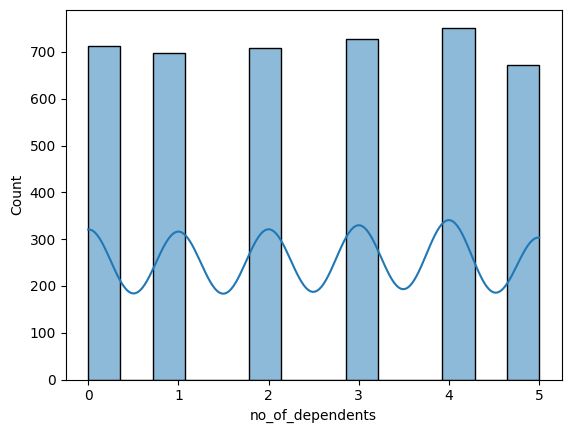

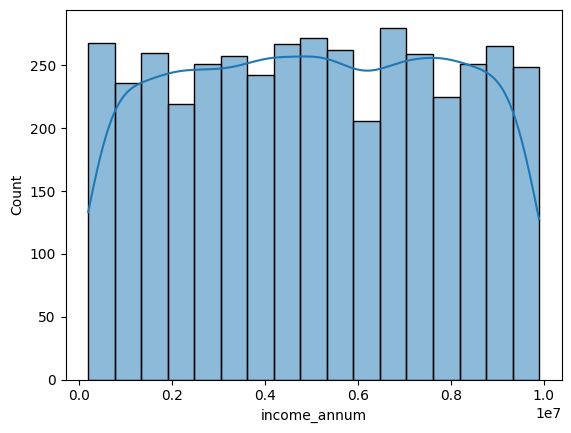

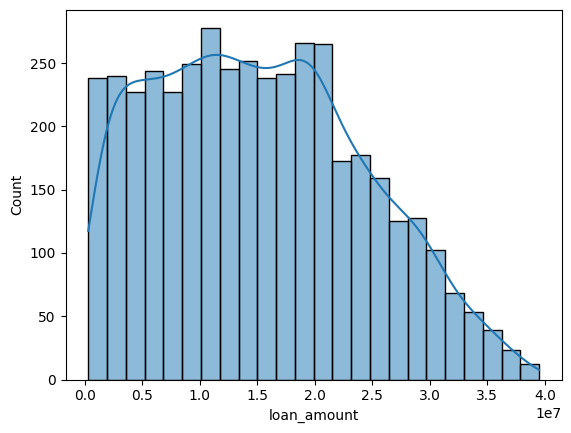

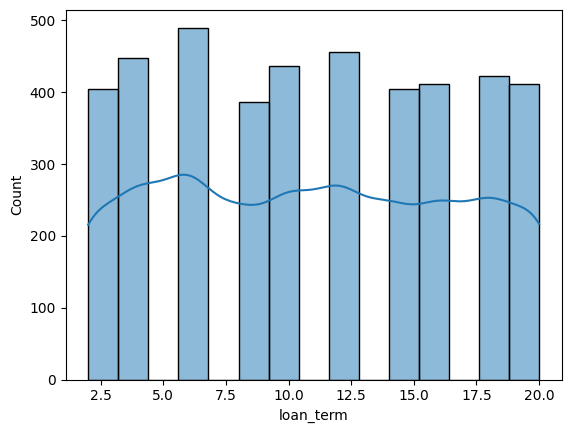

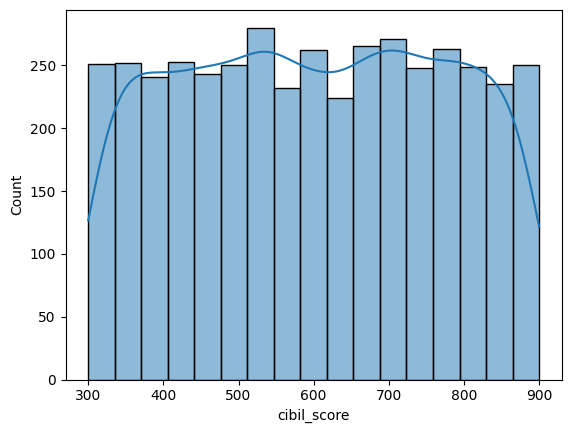

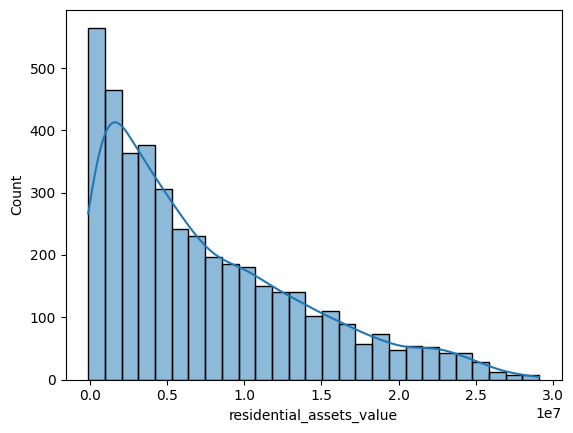

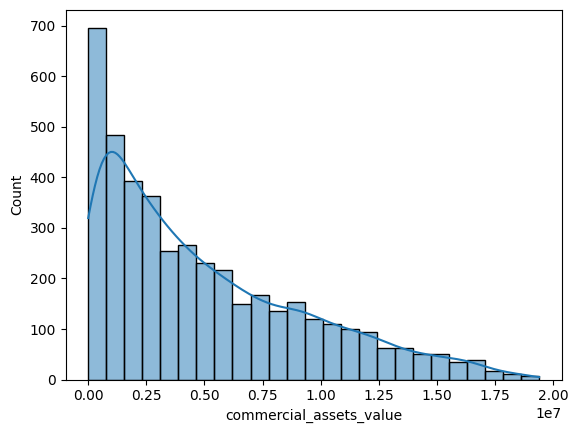

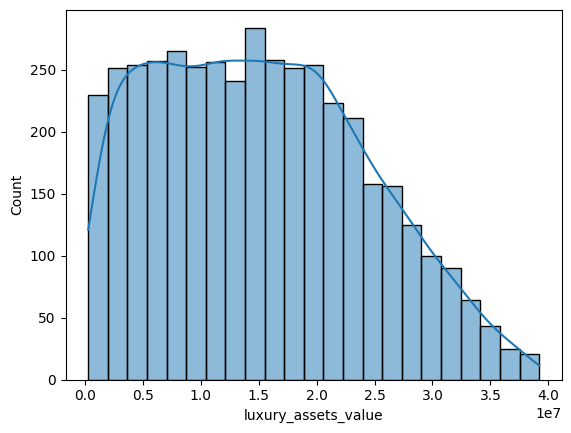

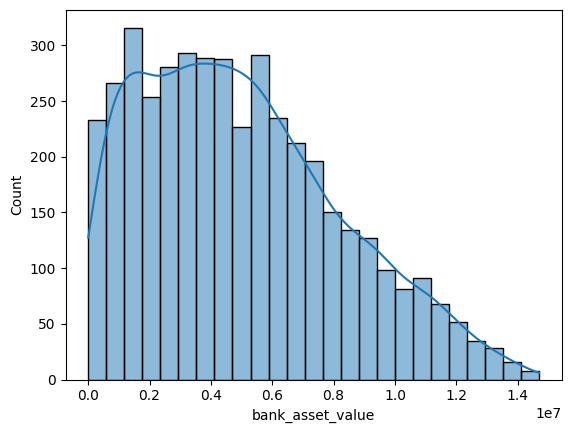

In [110]:
for col in numerical_columns:
    sns.histplot(loan_df[col], kde=True)
    plt.show()

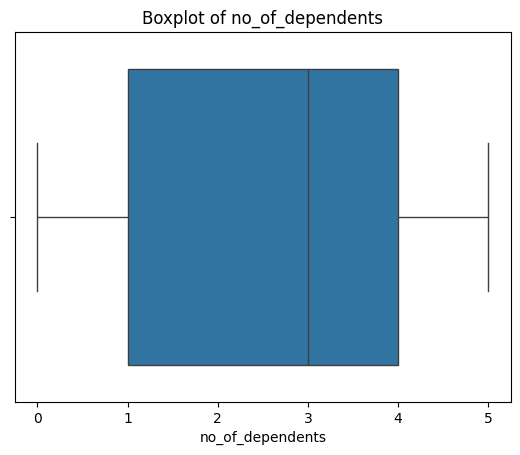

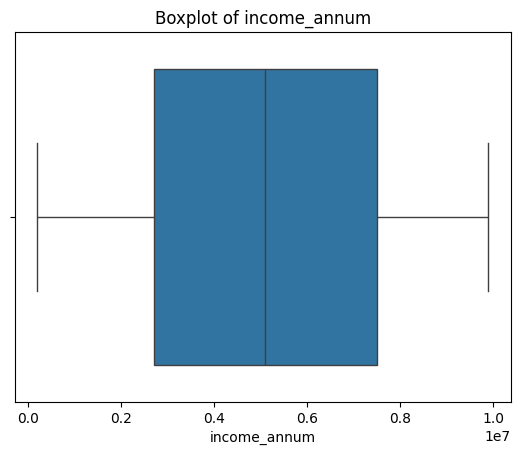

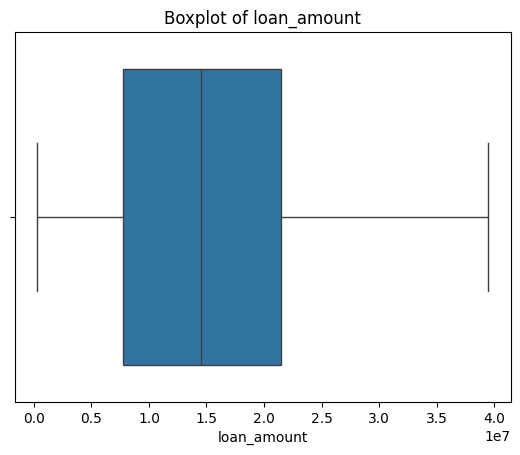

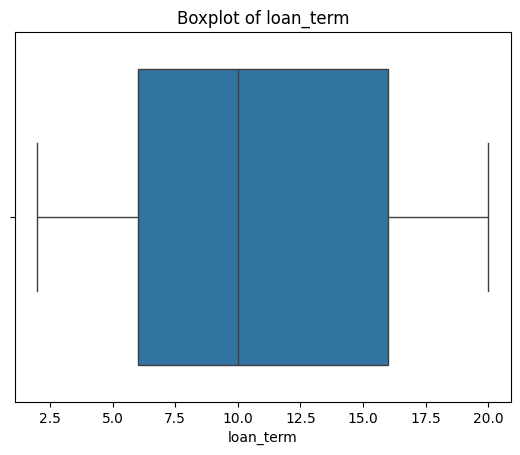

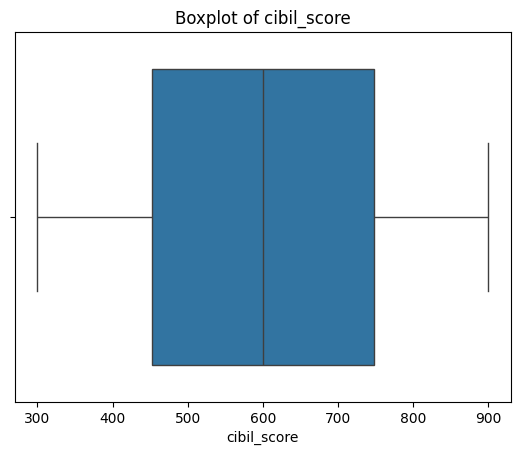

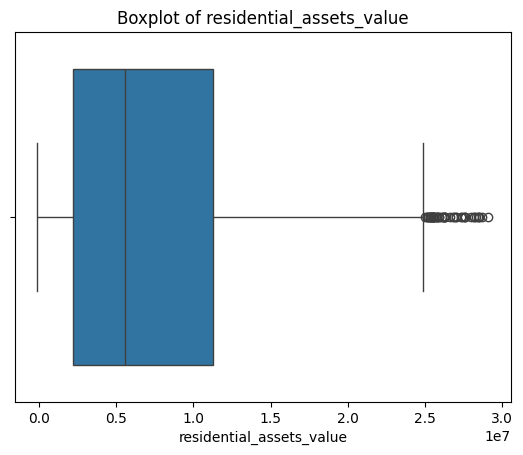

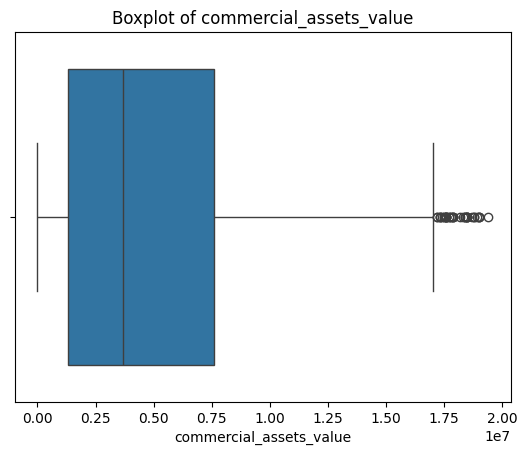

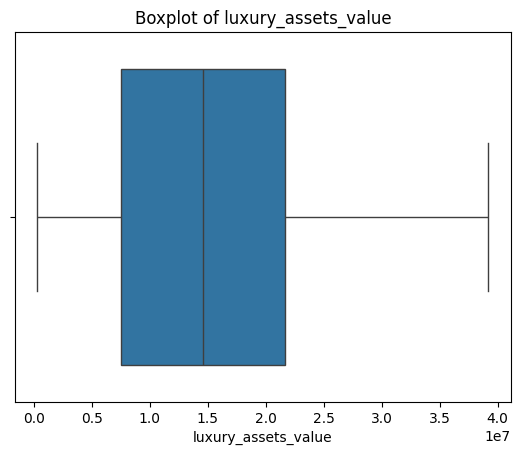

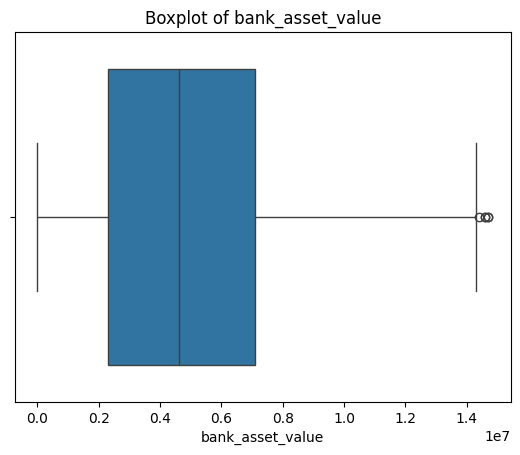

In [111]:
for col in numerical_columns:
    sns.boxplot(x=loan_df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

### Target Relationship

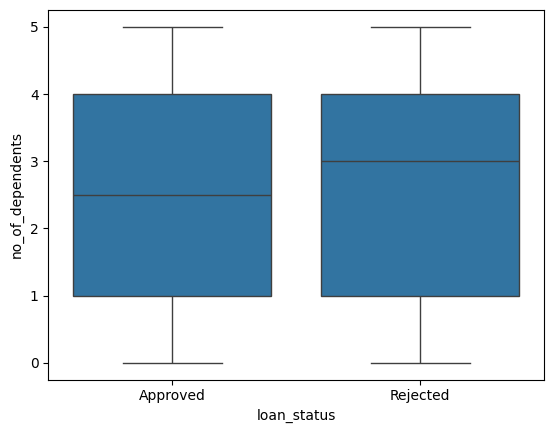

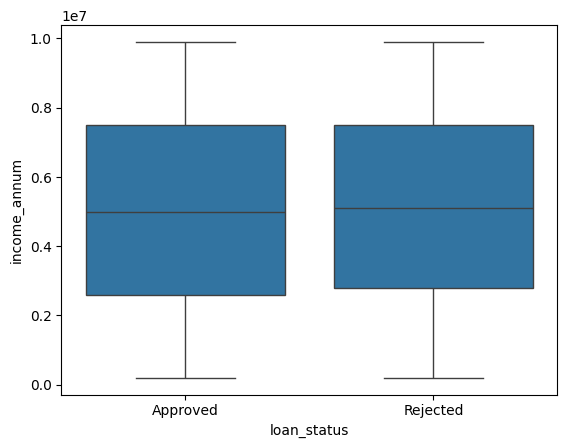

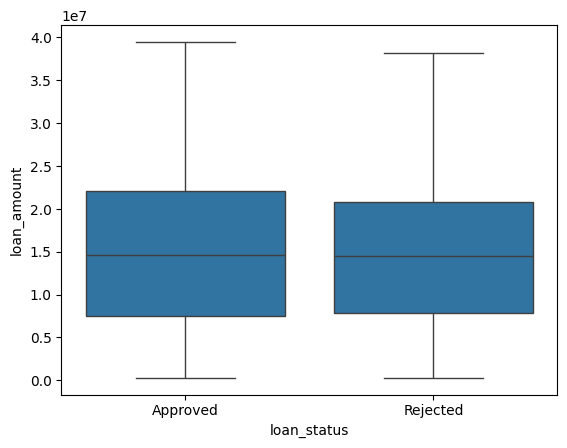

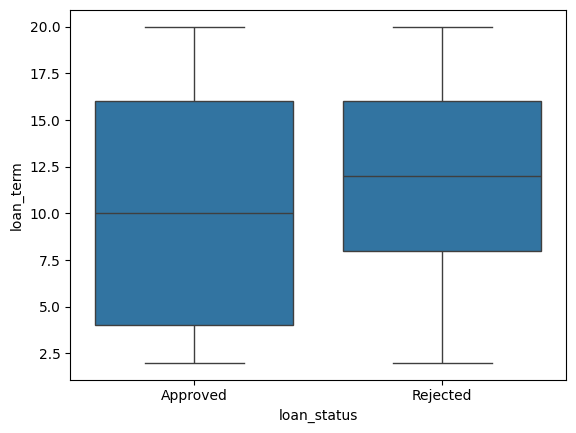

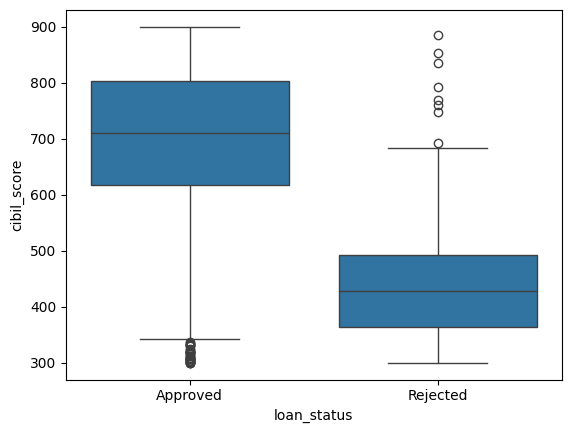

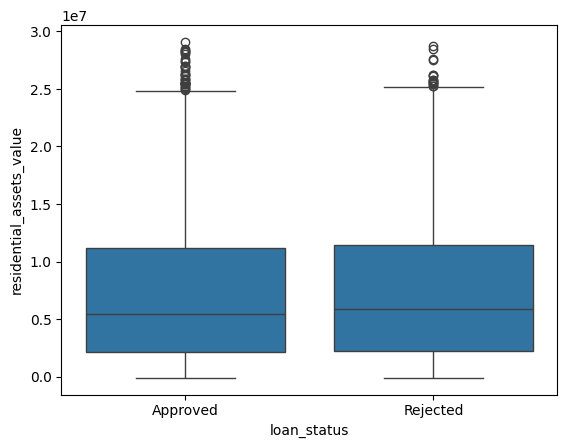

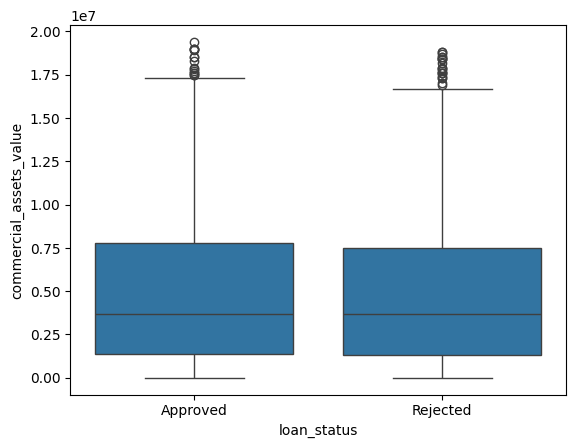

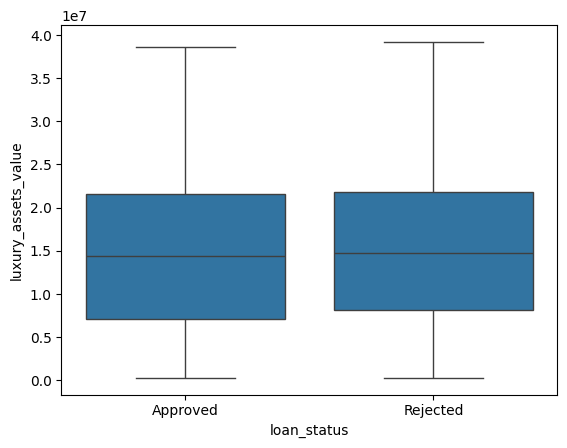

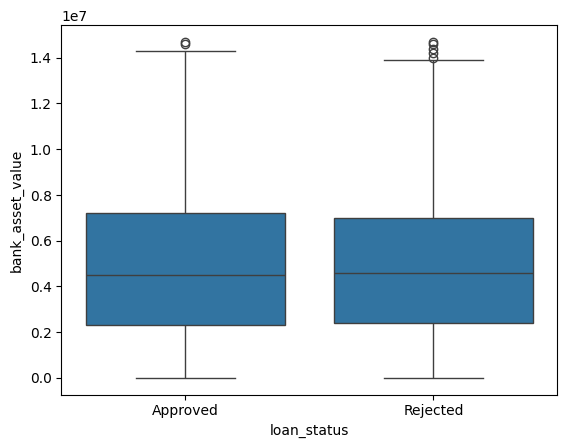

In [112]:
for col in numerical_columns:
    
    sns.boxplot(
        x="loan_status",
        y=col,
        data=loan_df
    )

    plt.show()

In [113]:
for col in categorical_cols:
    if col == "loan_status":
        pass
    else:
        crosstab= pd.crosstab(
            loan_df["loan_status"],
            loan_df[col]
        )
        print(f"{col}:\n{crosstab}\n")

education:
education    Graduate  Not Graduate
loan_status                        
Approved         1339          1317
Rejected          805           808

self_employed:
self_employed    No   Yes
loan_status              
Approved       1318  1338
Rejected        801   812



education:
loan_status   Approved  Rejected  Total  Approval_%  Rejected_%
education                                                      
Graduate          1339       805   2144       62.45       37.55
Not Graduate      1317       808   2125       61.98       38.02



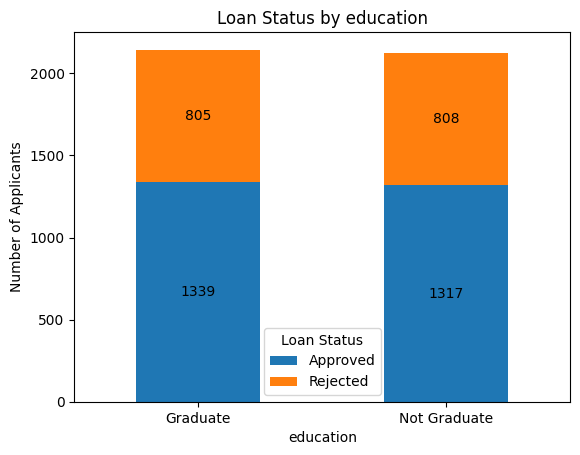

self_employed:
loan_status    Approved  Rejected  Total  Approval_%  Rejected_%
self_employed                                                   
No                 1318       801   2119       62.20       37.80
Yes                1338       812   2150       62.23       37.77



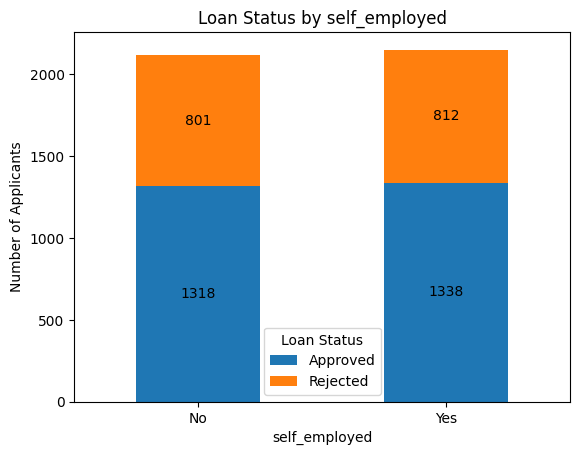

no_of_dependents:
loan_status       Approved  Rejected  Total  Approval_%  Rejected_%
no_of_dependents                                                   
0                      457       255    712       64.19       35.81
1                      430       267    697       61.69       38.31
2                      441       267    708       62.29       37.71
3                      457       270    727       62.86       37.14
4                      465       287    752       61.84       38.16
5                      406       267    673       60.33       39.67



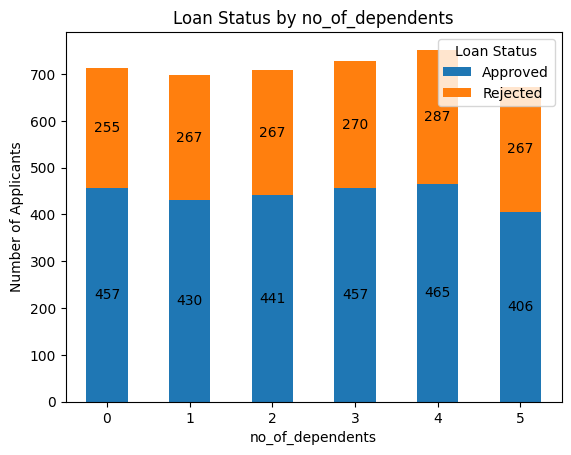

In [114]:
cols_to_analyze = list(categorical_cols)

if "no_of_dependents" not in cols_to_analyze:
    cols_to_analyze.append("no_of_dependents")

for col in cols_to_analyze:
    if col == "loan_status":
        continue

    status_table = pd.crosstab(
        loan_df[col],
        loan_df["loan_status"]
    )

    status_table["Total"] = status_table.sum(axis=1)
    status_table["Approval_%"] = status_table["Approved"] / status_table["Total"] * 100
    status_table["Rejected_%"] = status_table["Rejected"] / status_table["Total"] * 100

    print(f"{col}:\n{status_table}\n")

    ax = status_table[["Approved", "Rejected"]].plot(
        kind="bar",
        stacked=True
    )

    plt.title(f"Loan Status by {col}")
    plt.xlabel(col)
    plt.ylabel("Number of Applicants")
    plt.xticks(rotation=0)
    plt.legend(title="Loan Status")

    for container in ax.containers:
        ax.bar_label(container, label_type="center")

    plt.show()

### Conclusion:

* Education has very little relationship with loan approval.
    * This feature may have low predictive power.
    * Tree models may still use it slightly, but Logistic Regression likely assigns a very small coefficient.
* Being self-employed does not appear to affect approval significantly.
This feature may contribute little to the model.
* There is a slight downward trend as dependents increase, but the differences are small.
    * Weak relationship with loan approval.
    * May provide some predictive signal.
    * Much weaker than financial variables.

In [115]:
# Annual income vs loan status
income_status = loan_df.groupby(by=["loan_status"]).mean(numeric_only=True)["income_annum"]

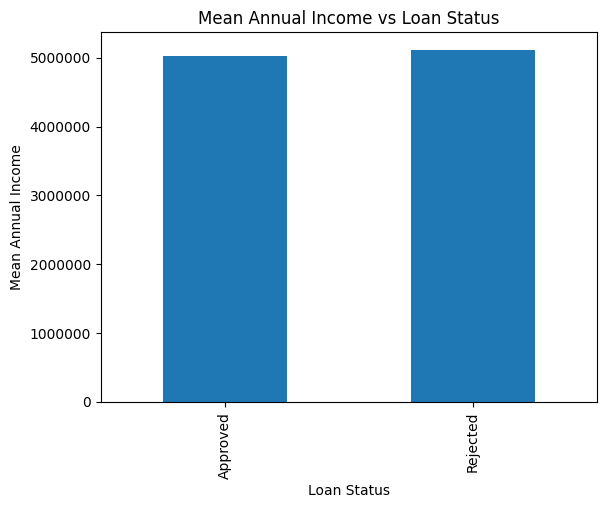

In [116]:
ax = income_status.plot(kind='bar')

ax.ticklabel_format(style='plain', axis='y')

plt.title("Mean Annual Income vs Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Mean Annual Income")
plt.xticks(rotation=90)

plt.show()

### From this data there is not much difference in approval criteria

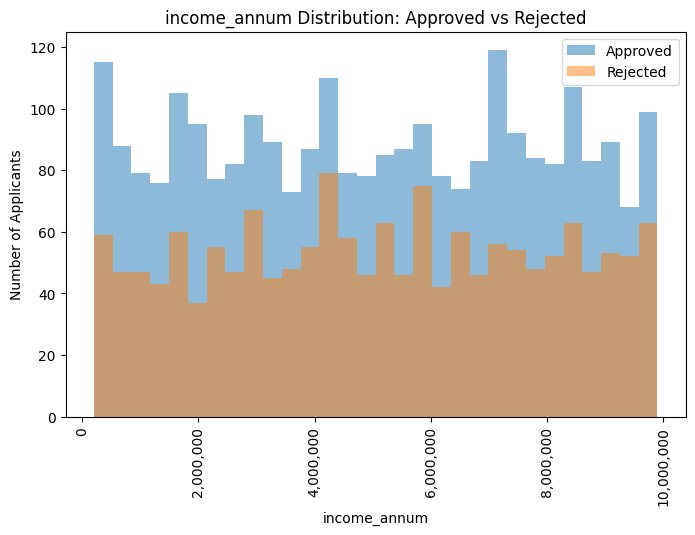

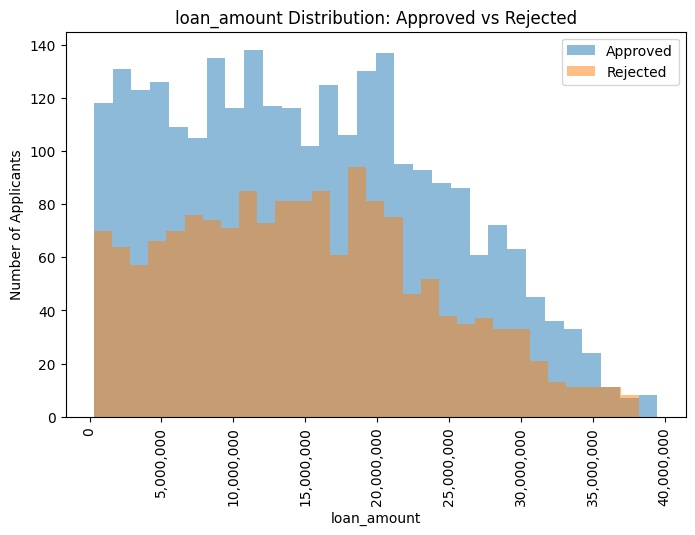

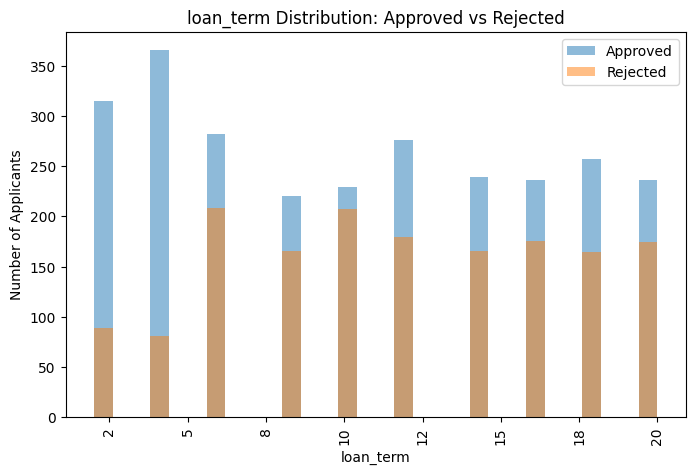

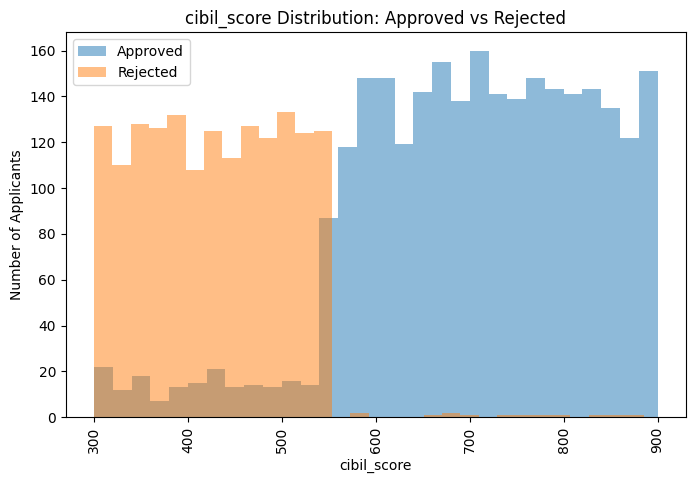

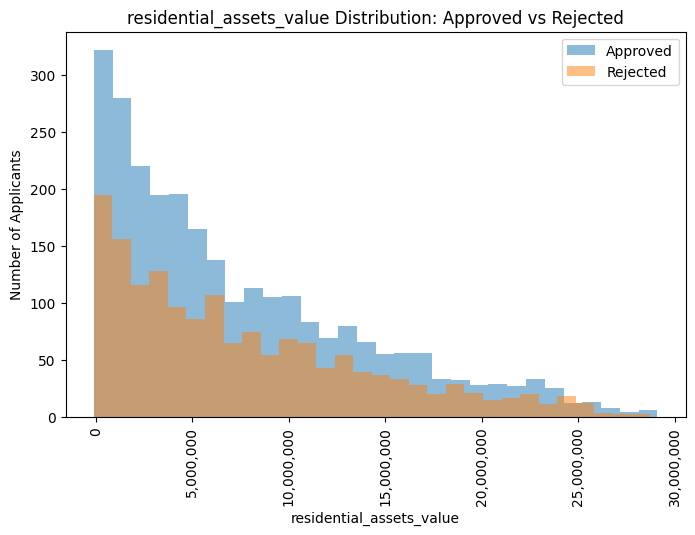

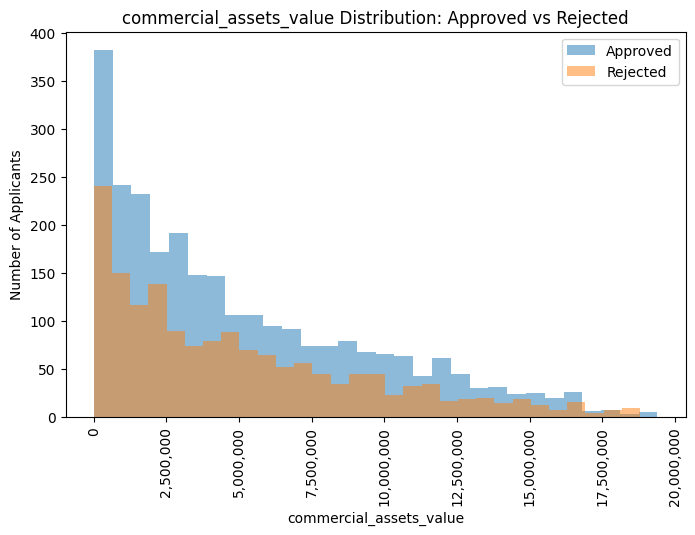

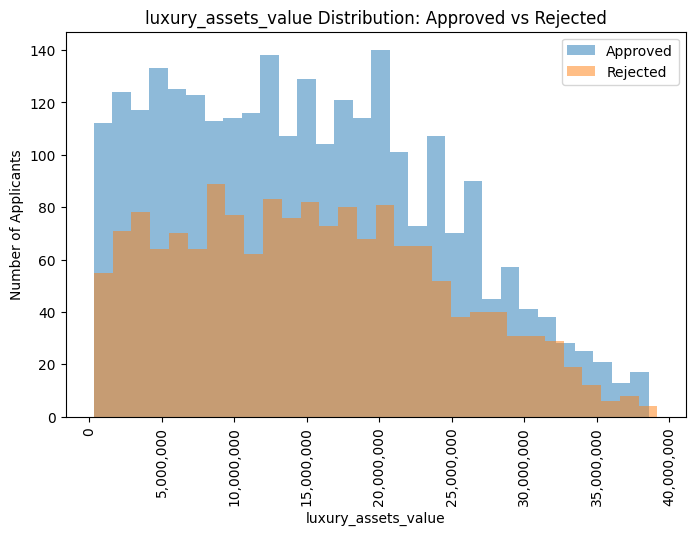

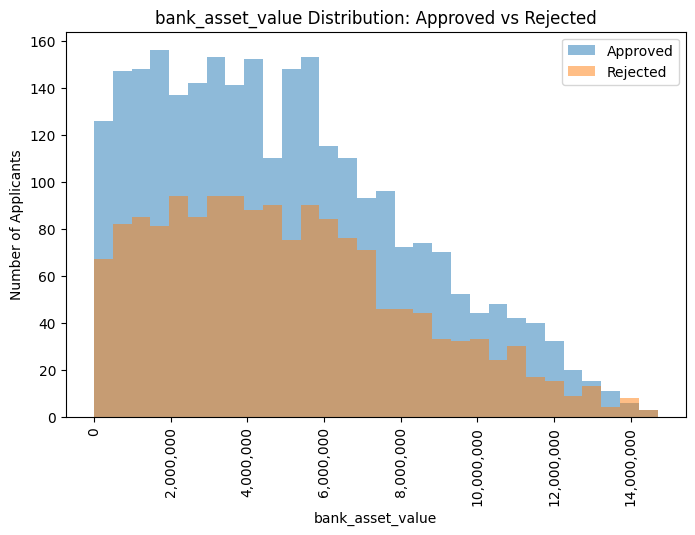

In [117]:
from matplotlib.ticker import StrMethodFormatter

for col in numerical_columns:
    if col == "no_of_dependents":
        continue

    approved_values = loan_df[loan_df["loan_status"] == "Approved"][col]
    rejected_values = loan_df[loan_df["loan_status"] == "Rejected"][col]

    plt.figure(figsize=(8, 5))
    plt.hist(approved_values, bins=30, alpha=0.5, label="Approved")
    plt.hist(rejected_values, bins=30, alpha=0.5, label="Rejected")

    plt.title(f"{col} Distribution: Approved vs Rejected")
    plt.xlabel(col)
    plt.ylabel("Number of Applicants")
    plt.legend()

    ax = plt.gca()
    ax.xaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))

    plt.xticks(rotation=90)
    plt.show()

### Conclusion:
* CIBIL Score: 
    * The cibil_score plot is almost perfectly separated.
    * Most rejected loans have CIBIL scores roughly 300–550
    * Most approved loans have scores roughly 550–900
    * Very little overlap
* Income
    * The income_annum distribution is almost identical for approved and rejected loans.
    * Observation:
        * Someone earning 9M can still get rejected.
        * Someone earning 2M can still get approved.
    * This suggests income alone isn't used for decisions.
* Loan Amount:
    * There is some separation. As loan amount increases:
        * approvals decrease
        * rejections become relatively more common
* Loan Term
    * Almost no visible separation.
    * The distributions look very similar.
* Asset Variables:
    * Residential Assets:
        * The distribution is right-skewed (many applicants have lower residential asset values, fewer have very high values).
        * Observation:
            * At almost every asset range, approved applicants outnumber rejected applicants.
            * As residential assets increase beyond roughly 15–20 million, rejections become relatively rare.
            * The tail of the distribution (20M–30M) is dominated by approved loans.
        * Residential property is often considered stable collateral. So the bank appears more willing to approve these applications.
    * Commercial Assets:
        * This plot shows the clearest asset-related signal.
        * Observation:
            * The highest concentration of rejected loans is in lower commercial asset ranges.
            * As commercial assets increase, approvals remain strong while rejections drop significantly.
            * Very high commercial asset holders are mostly approved.
        * Commercial assets generate income and can serve as collateral. This is why commercial assets often matter more than residential assets in lending decisions.
    * Luxury Assets:
        * This distribution is interesting. The separation is visible but weaker.
        * Observation:
            * Rejections exist across the entire range.
            * Approvals are consistently higher.
            * Even applicants with large luxury assets can still be rejected.
        * Luxury assets are less useful from a lending perspective because they can lose value quickly and are harder to liquidate. So the bank may consider them, but probably assigns less weight compared to residential or commercial assets.
    * Bank Asset Value:
        * This is one of the strongest asset variables.
        * Observation:
            * Approved loans dominate almost every range.
            * Higher bank balances show noticeably more approvals.
            * The right side of the distribution is heavily populated by approved applicants.
        * Cash in the bank is extremely valuable information for a lender. It directly reflects Liquidity, Emergency reserves, Ability to make payments, Financial discipline



##### The bank is probably not approving based on Income, Education, Self Employment, Dependents. Instead approvals appear driven by Creditworthiness (CIBIL), Ability to repay (Loan/Income Ratio), Collateral / Assets


In [118]:
numerical_columns

['no_of_dependents',
 'income_annum',
 'loan_amount',
 'loan_term',
 'cibil_score',
 'residential_assets_value',
 'commercial_assets_value',
 'luxury_assets_value',
 'bank_asset_value']

In [119]:
df = loan_df.copy()
df["total_assets"] = df["residential_assets_value"] + df["commercial_assets_value"] + df["luxury_assets_value"] + df["bank_asset_value"]
df["asset_coverage_ratio"] = df["total_assets"] / df["loan_amount"]
df["loan_income_ratio"] = df["loan_amount"] / df["income_annum"]
df["net_worth"] = df["total_assets"] - df["loan_amount"]
df.groupby("loan_status")[
    [
        "cibil_score",
        "loan_income_ratio",
        "asset_coverage_ratio",
        "net_worth"
    ]
].mean()

,cibil_score,loan_income_ratio,asset_coverage_ratio,net_worth
loan_status,,,,
Approved,703.46,3.03,2.21,17130045.18
Rejected,429.47,2.92,2.27,17885058.90


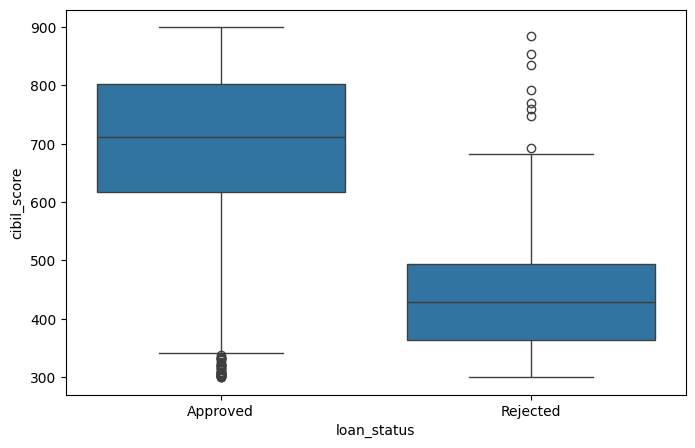

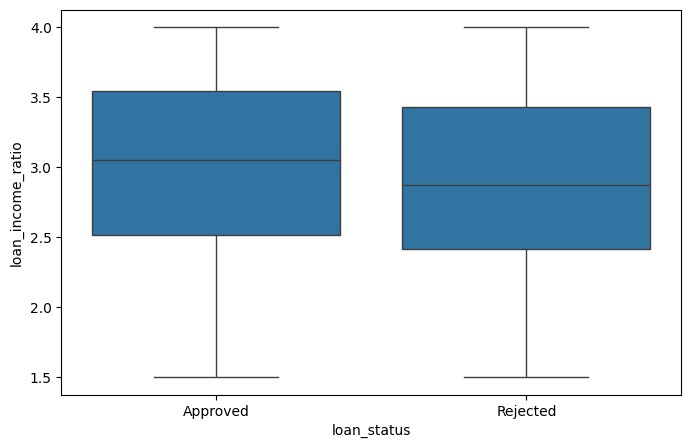

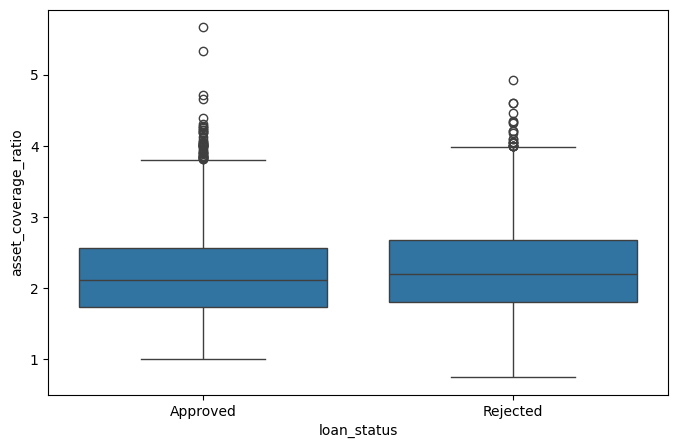

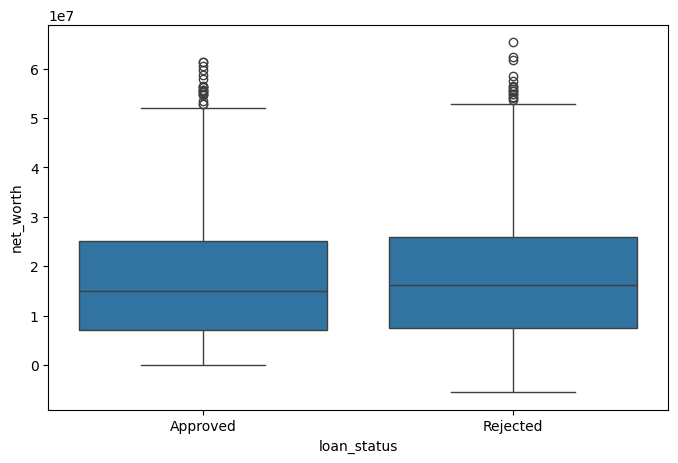

In [120]:
important_cols = [
    "cibil_score",
    "loan_income_ratio",
    "asset_coverage_ratio",
    "net_worth"
]

for col in important_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        data=df,
        x="loan_status",
        y=col
    )
    plt.show()

In [121]:
loan_df.groupby("loan_status")["cibil_score"].describe()

,count,mean,std,min,25%,50%,75%,max
loan_status,,,,,,,,
Approved,2656.00,703.46,125.25,300.00,618.00,711.00,803.00,900.00
Rejected,1613.00,429.47,78.40,300.00,364.00,429.00,493.00,885.00


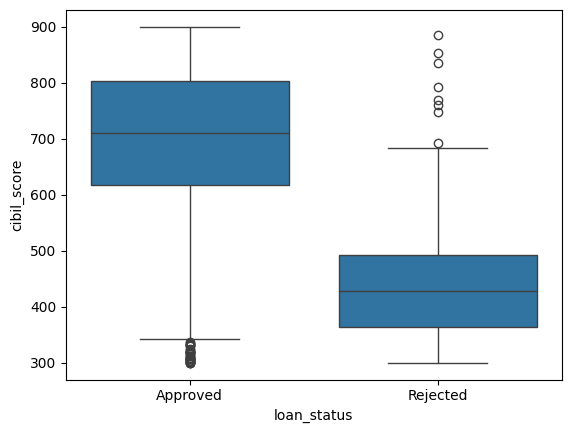

In [122]:
sns.boxplot(
    data=loan_df,
    x="loan_status",
    y="cibil_score"
)
plt.show()

In [123]:
loan_df.groupby(
    pd.cut(
        loan_df["cibil_score"],
        bins=[300,400,500,600,700,800,900]
    )
)["loan_status"].value_counts(normalize=True).unstack()*100

loan_status,Approved,Rejected
cibil_score,,
"(300, 400]",9.84,90.16
"(400, 500]",11.24,88.76
"(500, 600]",53.12,46.88
"(600, 700]",99.43,0.57
"(700, 800]",99.46,0.54
"(800, 900]",99.57,0.43


CIBIL score is the most influential feature in determining loan approval. Applicants with CIBIL scores above 600 have approval rates exceeding 99%, while applicants below 500 are rejected nearly 90% of the time. The approval rate changes dramatically in the 500–600 range, indicating that the lender's decision boundary is centered around a CIBIL score of approximately 600.

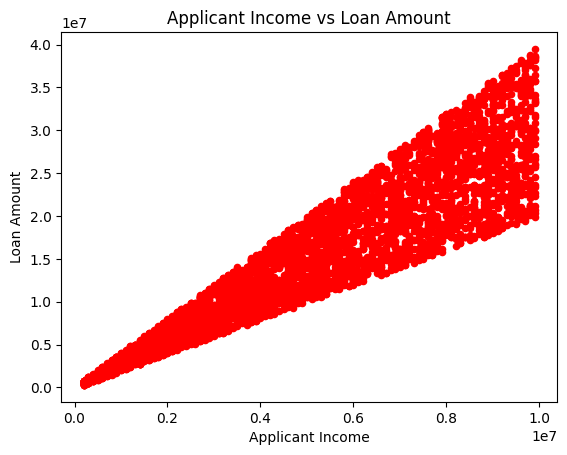

In [124]:
## Applicant income vs Loan Amount
loan_df.plot(x="income_annum", y="loan_amount", kind="scatter", color="red")
plt.title("Applicant Income vs Loan Amount")
plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.show()

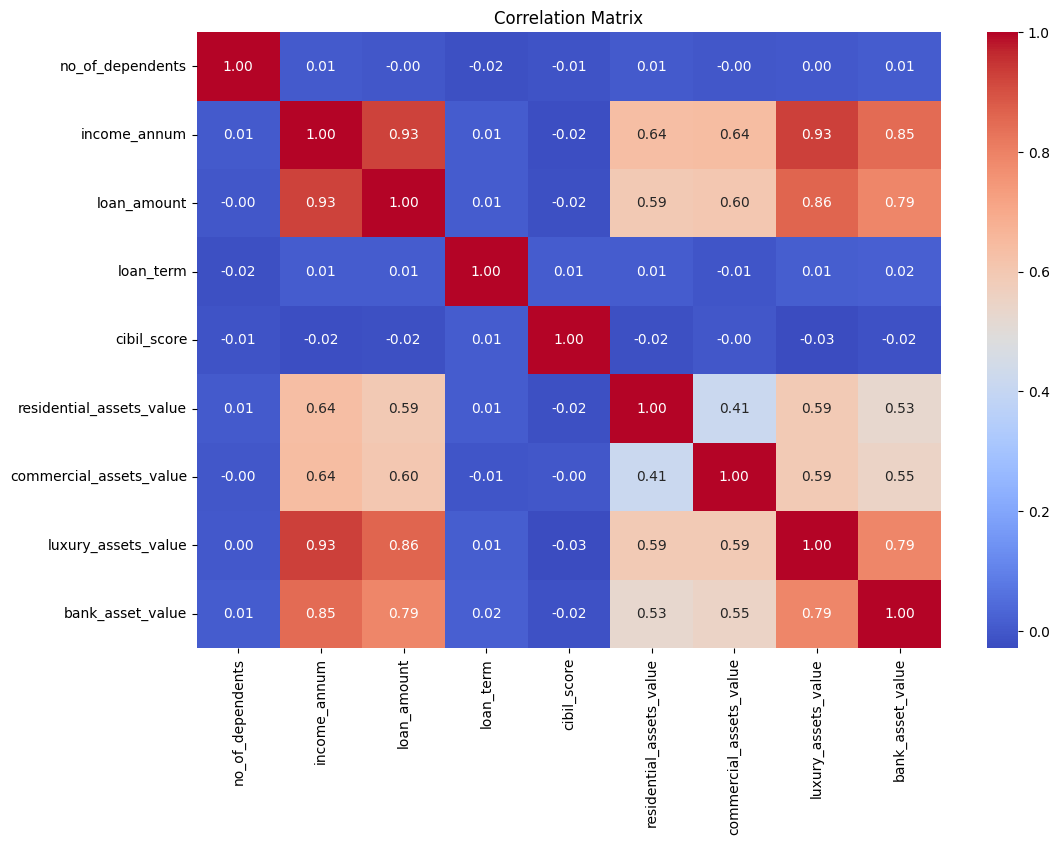

In [125]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    loan_df.select_dtypes(include=np.number).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

### Conclusion:
* Applicants with higher income tend to:
    * Apply for larger loans
    * Own more luxury assets
    * Have higher bank balances
* CIBIL score is independent, has correlations near -0.03 to 0.01
    * Credit score provides completely different information than income and assets.
* Everything is near zero for no_of_dependents and loan_term. They have almost no linear relationship with other features.

In [ ]:
df["loan_status_encoded"] = (
    df["loan_status"]
    .map({"Rejected": 0, "Approved": 1})
)

corr_target = (
    df.select_dtypes(include=np.number)
    .corr()["loan_status_encoded"]
    .sort_values(ascending=False)
)

print(corr_target)

loan_status_encoded         1.00
cibil_score                 0.77
loan_income_ratio           0.09
loan_amount                 0.02
commercial_assets_value     0.01
bank_asset_value           -0.01
total_assets               -0.01
residential_assets_value   -0.01
income_annum               -0.02
luxury_assets_value        -0.02
no_of_dependents           -0.02
net_worth                  -0.03
asset_coverage_ratio       -0.05
loan_term                  -0.11
Name: loan_status_encoded, dtype: float64


: 

### Key Findings
1. CIBIL score exhibited the strongest relationship with loan approval, showing a correlation of 0.77 with the target variable.
2. Applicants with CIBIL scores above 600 had approval rates exceeding 99%, while applicants below 500 experienced rejection rates close to 90%.
3. Demographic variables such as education, self-employment status, and number of dependents showed minimal influence on loan approval outcomes.
4. Financial variables including income, assets, and engineered ratios demonstrated weak linear relationships with the target.
5. Significant multicollinearity was observed among income, loan amount, luxury assets, and bank assets, indicating these variables capture similar financial information.
6. Overall, creditworthiness measured through CIBIL score emerged as the dominant factor driving loan approval decisions.